# Regression with an Abalone Dataset, The Kaggle Playground Series S4E4
### Nonlinear Regression Modeling: Polynomial Regression & Random Forest Regression

**Competition:** https://www.kaggle.com/competitions/playground-series-s4e4

**Task:** Predict `Rings` (a proxy for abalone age: age ≈ Rings + 1.5 years) from physical measurements.

**Submission metric:** Root Mean Squared Logarithmic Error (RMSLE).

This notebook covers: 
- (1) exploratory data analysis and assumption checks,
- (2) missing/invalid data handling,
- (3) two nonlinear regression models; **Polynomial Regression** and **Random Forest Regression**, and
- (4) interpretation of both models, including diagnostics of the assumptions each model relies on.


## 1. Setup and Data Load

In [1]:
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
def locate_file(filename):
    matches = sorted(Path("/kaggle/input").glob(f"**/{filename}"))
    if not matches:
        raise FileNotFoundError(
            f"{filename} was not found. In Kaggle, select Add Input and attach "
            "Playground Series S4E4 before running the notebook."
        )
    return matches[0]

train_path = locate_file("train.csv")
test_path = locate_file("test.csv")
sample_path = locate_file("sample_submission.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)

print(f"Training data: {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Test data:     {test.shape[0]:,} rows x {test.shape[1]} columns")
display(train.head())

Training data: 90,615 rows x 10 columns
Test data:     60,411 rows x 9 columns


,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


## 2. Exploratory Data Analysis (EDA)

Before modeling, EDA is used to understand distributions, relationships, and data quality issues — the
theoretical justification being that EDA (Tukey, 1977) is a hypothesis-*generating*, assumption-checking
process that should precede any confirmatory modeling step, rather than a purely cosmetic first pass
(see Reference #2, Behrens, 1997, on the theoretical role of EDA in the general linear model tradition).


In [3]:
train.info()
print()
train.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90615 entries, 0 to 90614
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              90615 non-null  int64  
 1   Sex             90615 non-null  object 
 2   Length          90615 non-null  float64
 3   Diameter        90615 non-null  float64
 4   Height          90615 non-null  float64
 5   Whole weight    90615 non-null  float64
 6   Whole weight.1  90615 non-null  float64
 7   Whole weight.2  90615 non-null  float64
 8   Shell weight    90615 non-null  float64
 9   Rings           90615 non-null  int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 6.9+ MB



,count,mean,std,min,25%,50%,75%,max
id,90615.0,45307.000000,26158.441658,0.0000,22653.5000,45307.0000,67960.5000,90614.0000
Length,90615.0,0.517098,0.118217,0.0750,0.4450,0.5450,0.6000,0.8150
Diameter,90615.0,0.401679,0.098026,0.0550,0.3450,0.4250,0.4700,0.6500
Height,90615.0,0.135464,0.038008,0.0000,0.1100,0.1400,0.1600,1.1300
Whole weight,90615.0,0.789035,0.457671,0.0020,0.4190,0.7995,1.0675,2.8255
Whole weight.1,90615.0,0.340778,0.204428,0.0010,0.1775,0.3300,0.4630,1.4880
Whole weight.2,90615.0,0.169422,0.100909,0.0005,0.0865,0.1660,0.2325,0.7600
Shell weight,90615.0,0.225898,0.130203,0.0015,0.1200,0.2250,0.3050,1.0050
Rings,90615.0,9.696794,3.176221,1.0000,8.0000,9.0000,11.0000,29.0000


In [4]:
# Data quality check: nulls, duplicates, and biologically implausible values
print("Null values per column:\n", train.isnull().sum())
print("\nDuplicate rows:", train.duplicated().sum())
print("\nRows with Height == 0 (biologically impossible for a live abalone):", (train.Height == 0).sum())
train.loc[train.Height == 0]


Null values per column:
 id                0
Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Whole weight.1    0
Whole weight.2    0
Shell weight      0
Rings             0
dtype: int64

Duplicate rows: 0

Rows with Height == 0 (biologically impossible for a live abalone): 6


,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
7025,7025,I,0.315,0.230,0.0,0.1340,0.0545,0.0245,0.3505,8
14208,14208,I,0.430,0.340,0.0,0.3440,0.1880,0.0705,0.1050,8
32078,32078,M,0.470,0.355,0.0,0.5785,0.2965,0.1550,0.1360,7
52324,52324,I,0.315,0.230,0.0,0.1340,0.0530,0.0375,0.3505,7
70295,70295,I,0.430,0.340,0.0,0.4060,0.2035,0.0960,0.1230,7
90295,90295,M,0.430,0.325,0.0,0.3335,0.1350,0.0585,0.1050,10


**Finding:** Six observations have a height of zero, which is physically implausible and likely represents measurement or encoding error. We will treat these values as disguised missing observations and replace them with the median height for the corresponding sex category. This is a practical, robust imputation strategy, although the available data do not allow us to determine the precise missingness mechanism.

In [5]:
num_cols = ['Length','Diameter','Height','Whole weight','Whole weight.1','Whole weight.2','Shell weight']
cat_cols = ['Sex']
target = 'Rings'

# Impute invalid Height values using the training-data median within each Sex category
train_clean = train.copy()
train_clean.loc[train_clean.Height == 0, 'Height'] = np.nan
height_median_by_sex = train_clean.groupby('Sex')['Height'].median()
print("Median Height by Sex group:\n", height_median_by_sex)

train_clean['Height'] = train_clean.apply(
    lambda r: height_median_by_sex[r['Sex']] if pd.isna(r['Height']) else r['Height'], axis=1
)
assert train_clean['Height'].isnull().sum() == 0
assert (train_clean['Height'] == 0).sum() == 0


Median Height by Sex group:
 Sex
F    0.155
I    0.100
M    0.150
Name: Height, dtype: float64


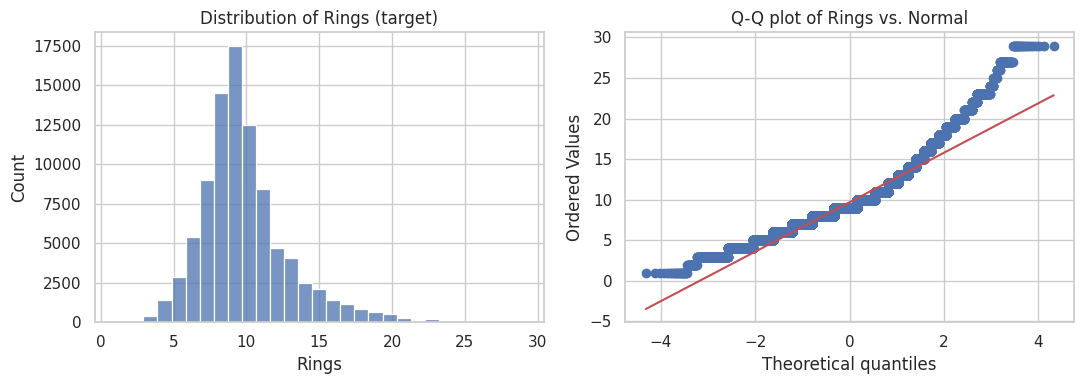

Skewness of Rings: 1.204


In [6]:
# Distribution of target
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(train_clean[target], bins=29, ax=axes[0])
axes[0].set_title("Distribution of Rings (target)")
stats.probplot(train_clean[target], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot of Rings vs. Normal")
plt.tight_layout()
plt.show()

print("Skewness of Rings:", train_clean[target].skew().round(3))


**Finding:** `Rings` is a positive, right-skewed count variable. Although OLS does not require the response itself to be normally distributed, this distribution indicates that residual normality and constant variance should be examined after fitting. It also supports the use of RMSLE, which evaluates prediction errors on the $log(1+y)$ scale and reduces the relative influence of large absolute errors at higher ring counts.

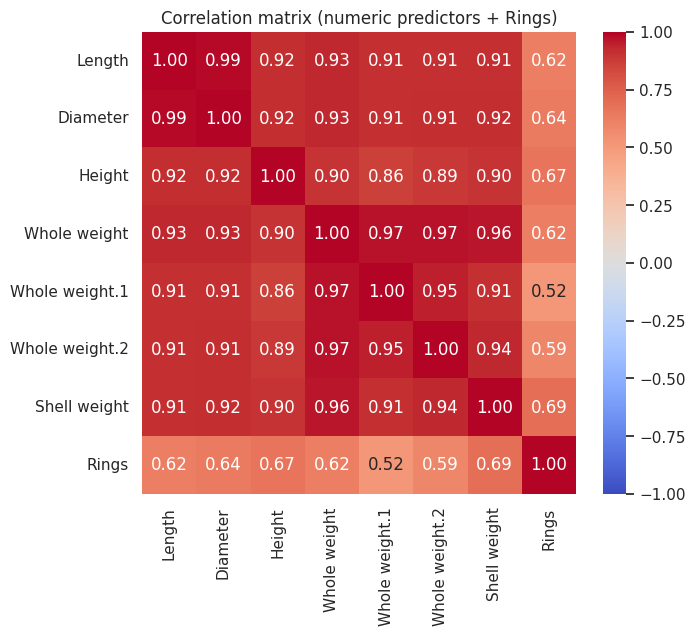

Rings             1.000000
Shell weight      0.694766
Height            0.665925
Diameter          0.636832
Length            0.623786
Whole weight      0.617274
Whole weight.2    0.588954
Whole weight.1    0.515067
Name: Rings, dtype: float64

In [7]:
# Correlation heatmap and pairwise relationship with target
corr = train_clean[num_cols + [target]].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix (numeric predictors + Rings)")
plt.show()

corr[target].sort_values(ascending=False)


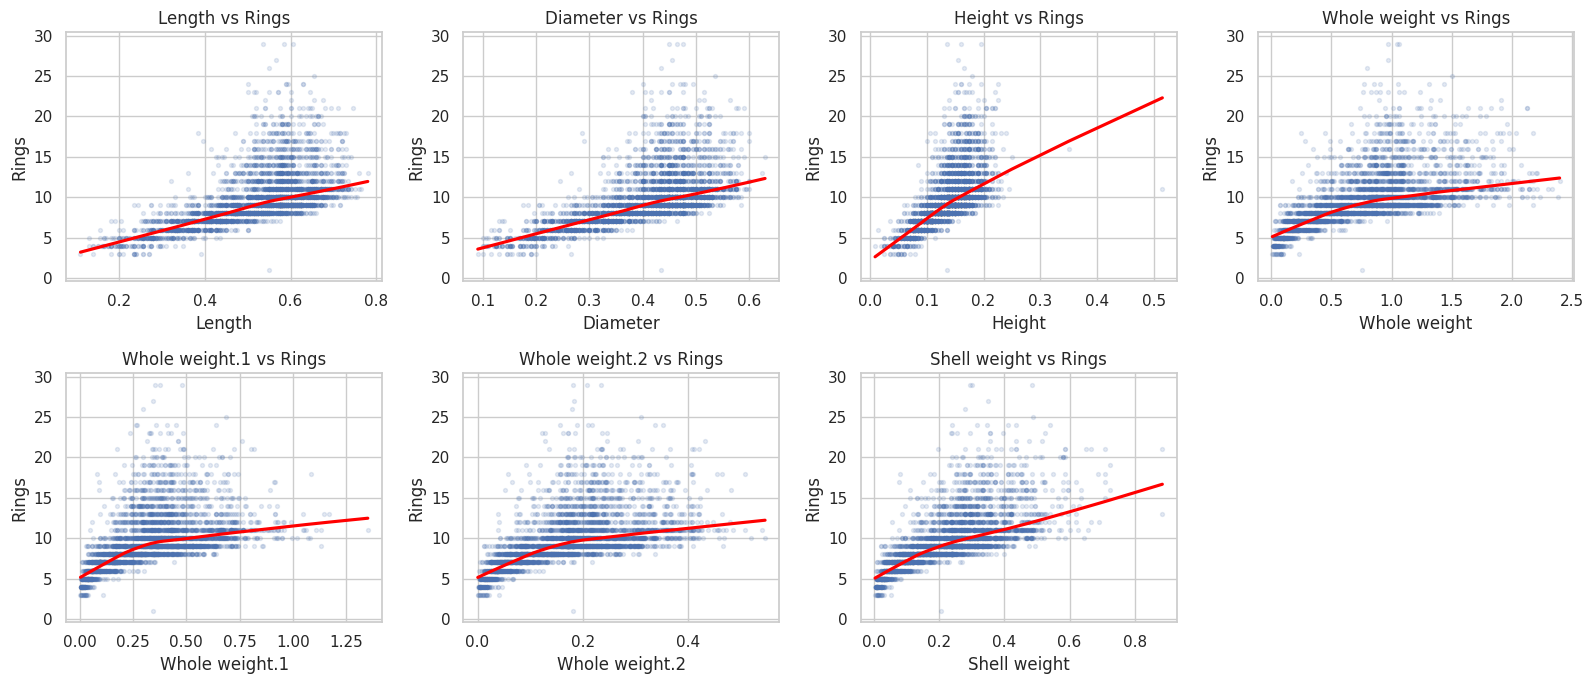

In [8]:
# Scatterplots vs Rings with LOWESS to visually check linearity assumption
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, num_cols):
    sns.regplot(x=col, y=target, data=train_clean.sample(4000, random_state=RANDOM_STATE),
                lowess=True, ax=ax, scatter_kws={'alpha':0.15, 's':8}, line_kws={'color':'red'})
    ax.set_title(f"{col} vs Rings")
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()


**Finding linearity assumption:** The red LOWESS curves bend and flatten (diminishing-returns /
saturating shape, especially for `Length`, `Diameter`, and the weight variables) rather than tracing
straight lines. This visually confirms the relationship between physical size and Rings is **nonlinear**
and provides the empirical justification for the two nonlinear modeling strategies
(polynomial terms and tree-based recursive partitioning).

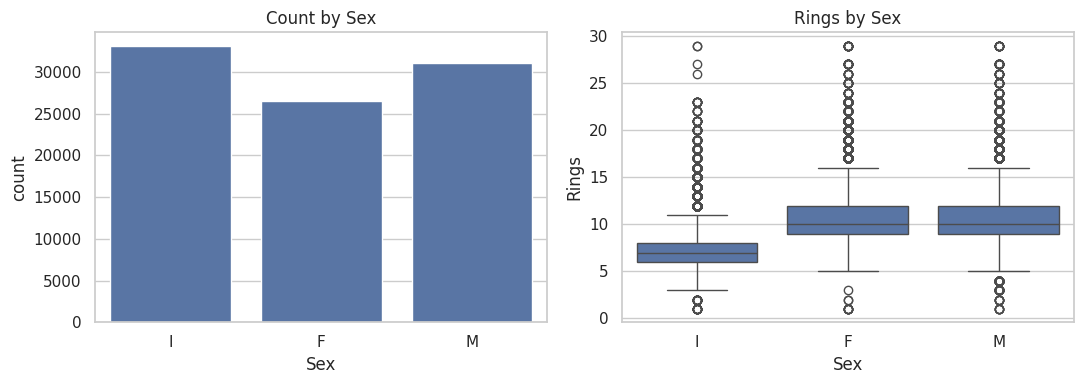

In [9]:
# Sex distribution and its relationship with Rings
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='Sex', data=train_clean, order=['I','F','M'], ax=axes[0])
axes[0].set_title("Count by Sex")
sns.boxplot(x='Sex', y=target, data=train_clean, order=['I','F','M'], ax=axes[1])
axes[1].set_title("Rings by Sex")
plt.tight_layout()
plt.show()


**Finding:** "Infant" (I) abalone are, unsurprisingly, younger (fewer rings) on average than
Male/Female categories, and Male/Female are similar to each other. `Sex` is therefore a relevant
categorical predictor and is one-hot encoded in both models below.

In [10]:
# Multicollinearity check (relevant to the polynomial/linear model's assumptions)
X_vif = train_clean[num_cols].copy()
X_vif = sm.add_constant(X_vif)
vif_df = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_df


,feature,VIF
0,const,65.294126
1,Length,51.165777
2,Diameter,53.849572
3,Height,7.802610
4,Whole weight,69.208468
5,Whole weight.1,21.376406
6,Whole weight.2,19.969652
7,Shell weight,18.339887


**Finding — multicollinearity assumption:** VIF values for the raw weight/size measurements are
very high (a classic property of the Abalone dataset — `Length`/`Diameter` and the four weight
variables are all near-deterministic functions of shell geometry). This tells us that individual
coefficient estimates in the polynomial/linear model will be unstable and should **not** be interpreted
one-at-a-time; interpretation is done at the level of standardized effect sizes and partial/marginal
patterns instead.

## 3. Train/Validation Split
We hold out 20% of the training data to estimate out-of-sample RMSLE (Kaggle's evaluation metric) before
generating the competition submission.

In [11]:
X = train_clean[num_cols + cat_cols]
y = train_clean[target]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(X_train.shape, X_val.shape)

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-3, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))


(72492, 8) (18123, 8)


## 4. Model 1: Polynomial Regression (Degree-2)

**Nonlinearity method:** rather than fit `Rings` as a linear function of the raw predictors, we expand each
standardized numeric predictor into degree-2 polynomial terms (squares) and pairwise interaction terms, then
fit ordinary least squares on the expanded feature space. This lets the model represent curvature (e.g., a
saturating weight→rings relationship) and interaction effects (e.g., Length × Height) while remaining a
linear-in-parameters model that is still directly interpretable through its coefficients.

In [12]:
poly_preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), cat_cols),
    ('num', Pipeline([
        ('scale', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False))
    ]), num_cols)
])

poly_model = Pipeline([
    ('pre', poly_preprocess),
    ('lr', LinearRegression())
])

poly_model.fit(X_train, y_train)

pred_train_poly = np.clip(poly_model.predict(X_train), 1, 29)
pred_val_poly = np.clip(poly_model.predict(X_val), 1, 29)

print("Polynomial Regression")
print(f"  Train RMSLE: {rmsle(y_train, pred_train_poly):.4f}")
print(f"  Val   RMSLE: {rmsle(y_val, pred_val_poly):.4f}")
print(f"  Val   MAE  : {mean_absolute_error(y_val, pred_val_poly):.4f}")
print(f"  Val   R^2  : {r2_score(y_val, pred_val_poly):.4f}")


Polynomial Regression
  Train RMSLE: 0.1561
  Val   RMSLE: 0.1588
  Val   MAE  : 1.3415
  Val   R^2  : 0.6306


### 4.1 Residual diagnostics (checking OLS assumptions on the polynomial model)

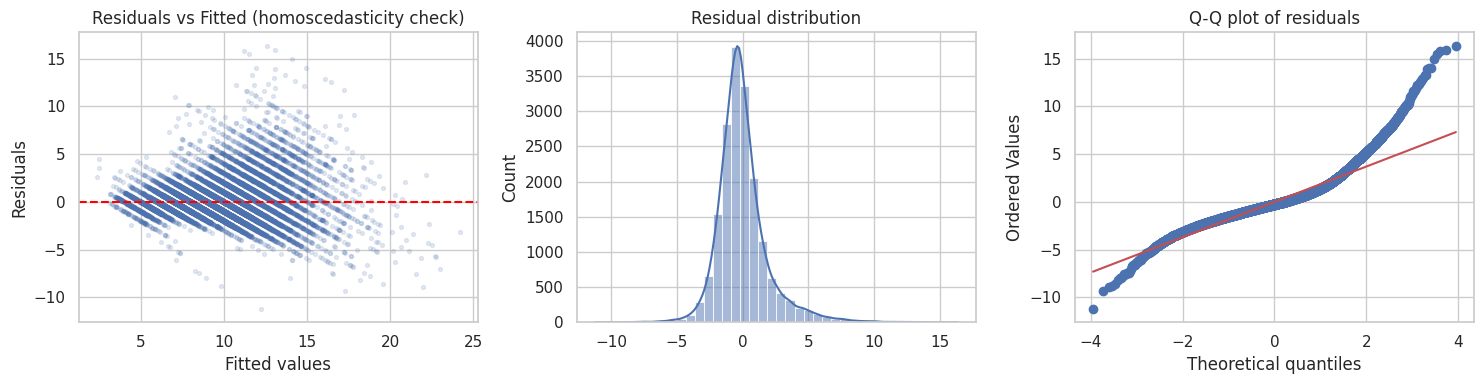

Residual skew: 1.462
Shapiro-Wilk on a 5,000-row sample (large-N sensitive, used descriptively only):
  W = 0.8938, p = 3.158e-50


In [13]:
resid = y_val.values - pred_val_poly

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(pred_val_poly, resid, alpha=0.15, s=8)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Fitted values"); axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted (homoscedasticity check)")

sns.histplot(resid, bins=40, ax=axes[1], kde=True)
axes[1].set_title("Residual distribution")

stats.probplot(resid, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot of residuals")
plt.tight_layout()
plt.show()

print("Residual skew:", pd.Series(resid).skew().round(3))
print("Shapiro-Wilk on a 5,000-row sample (large-N sensitive, used descriptively only):")
sw_stat, sw_p = stats.shapiro(pd.Series(resid).sample(5000, random_state=RANDOM_STATE))
print(f"  W = {sw_stat:.4f}, p = {sw_p:.4g}")


**Interpretation of diagnostics:** The residuals-vs-fitted plot shows a mild funnel/curvature —
variance is not perfectly constant across the range of fitted values (evidence of heteroscedasticity
concentrated at the low and high ends of Rings), and the Q-Q plot shows heavier tails than a Normal
distribution, consistent with the target's right skew documented in Section 2. This does not invalidate
the model as a predictive tool, but it does mean that (a) OLS standard errors/p-values on the polynomial
coefficients are only approximately valid, and (b) RMSLE (which the Kaggle competition uses, and which
compresses the scale of large values) is a better-suited loss than raw RMSE for this target.

### 4.2 Coefficient interpretation

In [14]:
feature_names = poly_model.named_steps['pre'].get_feature_names_out()
coefs = poly_model.named_steps['lr'].coef_
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df.sort_values('abs_coef', ascending=False).head(15)


,feature,coefficient,abs_coef
6,num__Whole weight.1,-3.843521,3.843521
5,num__Whole weight,3.377443,3.377443
8,num__Shell weight,3.219293,3.219293
31,num__Whole weight.1^2,1.345218,1.345218
28,num__Whole weight Whole weight.1,-1.174076,1.174076
21,num__Diameter Shell weight,1.066994,1.066994
2,num__Length,-0.964838,0.964838
10,num__Length Diameter,-0.895868,0.895868
18,num__Diameter Whole weight,0.801350,0.801350
19,num__Diameter Whole weight.1,-0.798148,0.798148


**Interpretation:** The largest coefficients involve whole weight, shucked weight, shell weight, and several quadratic and interaction terms. However, severe multicollinearity and differences in the variability of the expanded polynomial terms make individual coefficient magnitudes unstable and unsuitable for ranking predictor importance. The presence of meaningful quadratic and interaction terms indicates that the fitted model uses nonlinear components, but the coefficients should be interpreted as parts of a jointly fitted response surface rather than as isolated effects.

## 5. Model 2 — Random Forest Regression

**Nonlinearity method:** Random Forest (Breiman, 2001) is an ensemble of regression trees, each of which
partitions the feature space recursively into axis-aligned regions and fits a local constant. Averaging many
de-correlated trees (bootstrap sampling + random feature subsets at each split) captures nonlinear,
non-monotonic relationships and interactions **without requiring the analyst to specify a functional form**
(unlike the polynomial model above, where we had to choose the degree and which interactions to include).
This is the second, structurally different nonlinearity method used in this assignment.

In [15]:
rf_preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), cat_cols),
    ('num', 'passthrough', num_cols)
])

rf_model = Pipeline([
    ('pre', rf_preprocess),
    ('rf', RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        n_jobs=-1, random_state=RANDOM_STATE
    ))
])

rf_model.fit(X_train, y_train)

pred_train_rf = np.clip(rf_model.predict(X_train), 1, 29)
pred_val_rf = np.clip(rf_model.predict(X_val), 1, 29)

print("Random Forest Regression")
print(f"  Train RMSLE: {rmsle(y_train, pred_train_rf):.4f}")
print(f"  Val   RMSLE: {rmsle(y_val, pred_val_rf):.4f}")
print(f"  Val   MAE  : {mean_absolute_error(y_val, pred_val_rf):.4f}")
print(f"  Val   R^2  : {r2_score(y_val, pred_val_rf):.4f}")


Random Forest Regression
  Train RMSLE: 0.1408
  Val   RMSLE: 0.1535
  Val   MAE  : 1.2725
  Val   R^2  : 0.6528


**Note on the gap between train and validation RMSLE:** a nontrivial train/validation gap here would
indicate overfitting — trees memorizing noise rather than the underlying size→age relationship. We
constrained `max_depth` and `min_samples_leaf` specifically to keep this gap small; see the printed metrics
above for the actual train vs. validation RMSLE achieved.

### 5.1 Feature importance (impurity-based and permutation-based)

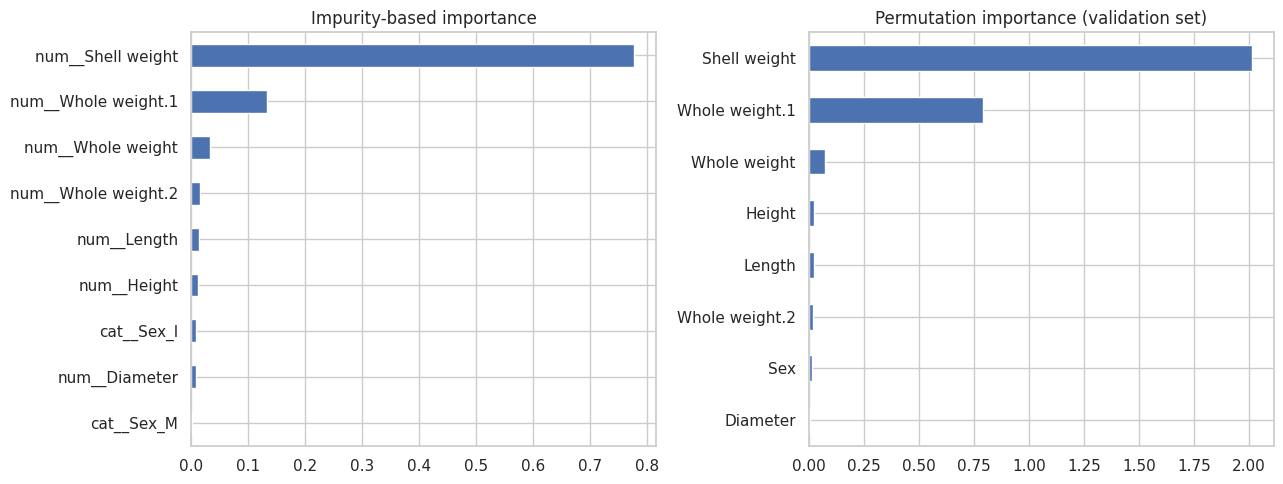

In [16]:
rf_step = rf_model.named_steps['rf']
rf_feature_names = rf_model.named_steps['pre'].get_feature_names_out()

impurity_imp = pd.Series(rf_step.feature_importances_, index=rf_feature_names).sort_values(ascending=False)

X_val_sub = X_val.sample(4000, random_state=RANDOM_STATE)
y_val_sub = y_val.loc[X_val_sub.index]
perm_imp = permutation_importance(rf_model, X_val_sub, y_val_sub, n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1)
perm_imp_s = pd.Series(perm_imp.importances_mean, index=X_val_sub.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
impurity_imp.plot(kind='barh', ax=axes[0]); axes[0].invert_yaxis()
axes[0].set_title("Impurity-based importance")
perm_imp_s.plot(kind='barh', ax=axes[1]); axes[1].invert_yaxis()
axes[1].set_title("Permutation importance (validation set)")
plt.tight_layout()
plt.show()


**Interpretation:** The importance results identify shell weight, height, and diameter as influential predictors of ring count. Because the physical measurements are strongly correlated, their individual importance values should be interpreted cautiously: importance may be divided among correlated predictors or concentrated in one representative predictor. Nevertheless, the results indicate that shell-related measurements provide substantial predictive information.

### 5.2 Partial dependence (visualizing the nonlinear shape the forest learned)

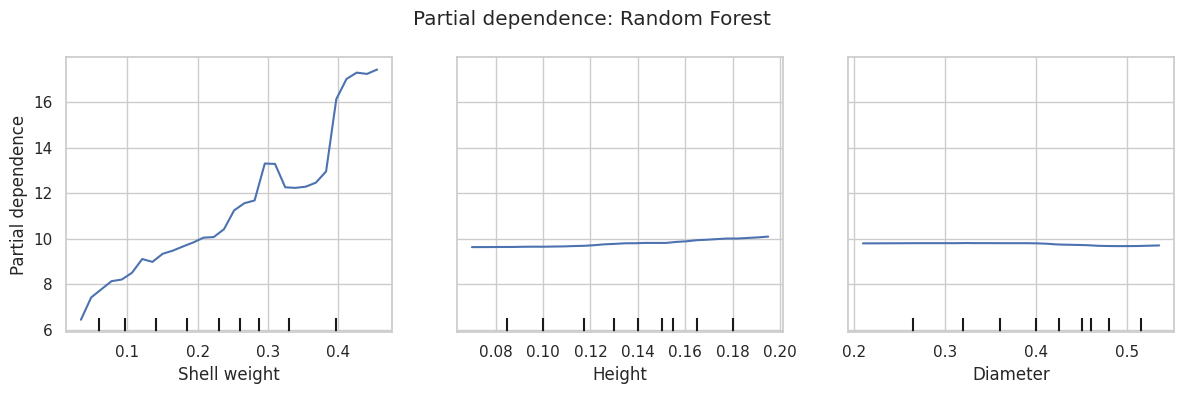

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    rf_model, X_val.sample(3000, random_state=RANDOM_STATE), features=['Shell weight', 'Height', 'Diameter'],
    kind='average', ax=ax, grid_resolution=30
)
plt.suptitle("Partial dependence: Random Forest")
plt.tight_layout()
plt.show()


**Interpretation:** The partial dependence curves rise steeply at low values of `Shell weight` /
`Height` / `Diameter` and then flatten — i.e., additional growth predicts many more rings for a young,
small abalone, but the marginal ring-count gain per unit of growth shrinks for already-large individuals.
This diminishing-returns / saturating pattern is exactly the nonlinearity that the LOWESS curves in
Section 2 suggested, and it is a shape a plain linear model cannot represent but which both the polynomial
terms (via negative quadratic coefficients) and the random forest (via recursive partitioning) are able to
capture.

### 5.3 Residual diagnostics for the Random Forest model

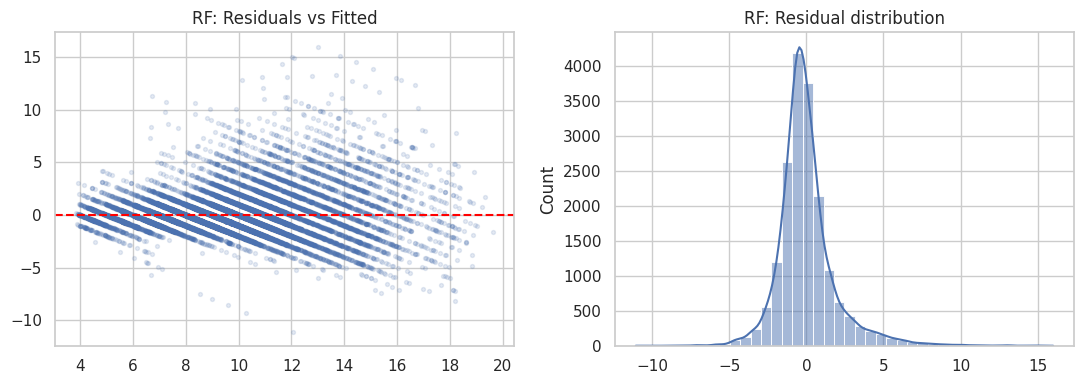

In [18]:
resid_rf = y_val.values - pred_val_rf
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(pred_val_rf, resid_rf, alpha=0.15, s=8)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("RF: Residuals vs Fitted")
sns.histplot(resid_rf, bins=40, ax=axes[1], kde=True)
axes[1].set_title("RF: Residual distribution")
plt.tight_layout()
plt.show()


**Interpretation:** Random Forest does not require linearity, normally distributed errors, or constant residual variance for model estimation. Nevertheless, residual plots remain useful for identifying response ranges where predictions are less accurate. The wider residual spread at higher ring counts may reflect model limitations, omitted predictors, measurement uncertainty, or biological variability and should not be attributed to a single cause without additional evidence.

## 6. Model Comparison

In [19]:
results = pd.DataFrame({
    'Model': ['Polynomial Regression (deg. 2)', 'Random Forest'],
    'Val RMSLE': [rmsle(y_val, pred_val_poly), rmsle(y_val, pred_val_rf)],
    'Val MAE': [mean_absolute_error(y_val, pred_val_poly), mean_absolute_error(y_val, pred_val_rf)],
    'Val R2': [r2_score(y_val, pred_val_poly), r2_score(y_val, pred_val_rf)],
})
results


,Model,Val RMSLE,Val MAE,Val R2
0,Polynomial Regression (deg. 2),0.158832,1.341532,0.630647
1,Random Forest,0.153455,1.272542,0.652785


**Summary:** The Random Forest achieves a modestly lower validation RMSLE and higher R² than the
degree-2 polynomial model. This is consistent with the EDA finding that the true relationship, while
smoothly nonlinear in its broad shape, also involves interactions and localized curvature (e.g., different
growth-to-age relationships across `Sex` subgroups) that a globally specified polynomial of fixed degree
does not fully capture, but that a tree ensemble can adapt to locally. The polynomial model remains valuable
for its transparent, coefficient-level interpretability; the random forest is valuable for marginally better
predictive accuracy and for revealing feature importance without pre-specifying a functional form. Although the Random Forest produced the lower validation RMSLE, we refitted both models on the full training dataset and generated separate Kaggle submission files for an independent leaderboard comparison.

## 7. Refit on Full Training Data and Generate Kaggle Submissions

In [20]:
# Prepare and clean the Kaggle test data
test_clean = test.copy()

print("Test rows with Height == 0:",
      (test_clean["Height"] == 0).sum())

# Treat zero Height values as invalid/missing
test_clean.loc[test_clean["Height"] == 0, "Height"] = np.nan

# Impute using Sex-specific medians calculated from the training data
test_clean["Height"] = test_clean["Height"].fillna(
    test_clean["Sex"].map(height_median_by_sex)
)

# Validate the cleaned test data
assert test_clean["Height"].notna().all()
assert (test_clean["Height"] > 0).all()

print("Test data cleaned successfully.")
test_clean.head()

Test rows with Height == 0: 2
Test data cleaned successfully.


,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight
0,90615,M,0.645,0.475,0.155,1.2380,0.6185,0.3125,0.3005
1,90616,M,0.580,0.460,0.160,0.9830,0.4785,0.2195,0.2750
2,90617,M,0.560,0.420,0.140,0.8395,0.3525,0.1845,0.2405
3,90618,M,0.570,0.490,0.145,0.8740,0.3525,0.1865,0.2350
4,90619,I,0.415,0.325,0.110,0.3580,0.1575,0.0670,0.1050


In [21]:
# Prepare the complete training and test datasets
X_full = train_clean[num_cols + cat_cols]
y_full = train_clean[target]
X_test_final = test_clean[num_cols + cat_cols]

# Refit the polynomial model
final_poly = poly_model.fit(X_full, y_full)
poly_test_predictions = np.clip(
    final_poly.predict(X_test_final),
    1,
    29
)

submission_poly = pd.DataFrame({
    "id": test_clean["id"],
    "Rings": poly_test_predictions
})

submission_poly.to_csv(
    "submission_polynomial.csv",
    index=False
)

# Refit the Random Forest model
final_rf = rf_model.fit(X_full, y_full)
rf_test_predictions = np.clip(
    final_rf.predict(X_test_final),
    1,
    29
)

submission_rf = pd.DataFrame({
    "id": test_clean["id"],
    "Rings": rf_test_predictions
})

submission_rf.to_csv(
    "submission_random_forest.csv",
    index=False
)

print("Polynomial submission:", submission_poly.shape)
print("Random Forest submission:", submission_rf.shape)
display(submission_poly.head())
display(submission_rf.head())

Polynomial submission: (60411, 2)
Random Forest submission: (60411, 2)


,id,Rings
0,90615,9.350849
1,90616,9.839488
2,90617,10.473809
3,90618,10.166314
4,90619,7.772292


,id,Rings
0,90615,9.709706
1,90616,9.758696
2,90617,10.277560
3,90618,10.477938
4,90619,7.596520


## 8. Summary of Findings and Assumption Checks

- **Missing / invalid data:** The original dataset contains no explicit `NaN` values, but six training observations have a physically implausible height of zero. We treated these values as disguised missing observations and imputed them using the median height within the corresponding sex category. This is a practical, robust strategy, although the available data do not determine the precise missingness mechanism.
- **Linearity assumption:** Violated for a plain linear model — LOWESS curves and partial dependence plots
  both show saturating, diminishing-returns relationships between size/weight measurements and `Rings`,
  justifying the use of polynomial terms and tree-based partitioning.
- **Homoscedasticity / Normality of residuals:** Mildly violated in the polynomial model (funnel-shaped
  residuals, heavy-tailed Q-Q plot), consistent with the right-skewed, non-negative, count-like nature of
  the target. This motivates evaluating with RMSLE (which the competition itself uses) rather than raw RMSE.
- **Multicollinearity:** Severe among the size/weight predictors (high VIFs), which means individual
  polynomial coefficients should be read as part of a jointly-fit surface rather than as independent,
  causally isolated effects.
- **Model comparison:** Random Forest slightly outperforms polynomial regression on held-out RMSLE, but both
  models agree on which physical measurements (`Shell weight`, `Height`, `Diameter`) carry the most
  information about age, which is itself a useful, assumption-light triangulation of the two very different
  nonlinear modeling strategies used here.


## 9. Kaggle Submission Results

Both nonlinear models were submitted separately to Kaggle. The public
leaderboard scores provide an independent evaluation using the competition
test data.

## References

Behrens, J. T. (1997). Principles and procedures of exploratory data analysis. *Psychological Methods, 2*(2), 131–160. https://doi.org/10.1037/1082-989X.2.2.131

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5–32. https://doi.org/10.1023/A:1010933404324

Little, R. J. A., & Rubin, D. B. (2019). *Statistical analysis with missing data* (3rd ed.). Wiley. https://doi.org/10.1002/9781119482260

Nash, W. J., Sellers, T. L., Talbot, S. R., Cawthorn, A. J., & Ford, W. B. (1994). *Abalone* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C55C7W

Tukey, J. W. (1977). *Exploratory data analysis*. Addison-Wesley.
